# CatBoost — Playground Series S6E4: Predicting Irrigation Need

CatBoost with three named hyperparameter configurations plus Optuna tuning.
Reports macro F1, accuracy, and balanced accuracy (competition metric).

CatBoost differs from XGBoost and LightGBM in two important ways:
1. **Symmetric (oblivious) decision trees** — every node at the same depth uses the same split condition, producing balanced trees that are faster to evaluate and more resistant to overfitting.
2. **Built-in categorical handling** — CatBoost uses ordered target statistics internally, so no manual encoding (LabelEncoder, one-hot, etc.) is needed. We pass string columns directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             classification_report)

from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv')
print(f'Train: {train.shape}, Test: {test.shape}')

Train: (630000, 21), Test: (270000, 20)


In [3]:
# preprocessing — CatBoost handles categoricals natively, just specify which columns
X = train.drop(columns=['id', 'Irrigation_Need'])
y = train['Irrigation_Need']
X_test = test.drop(columns=['id'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

target_le = LabelEncoder()
y_enc = target_le.fit_transform(y)
print('Classes:', dict(zip(target_le.classes_, range(len(target_le.classes_)))))
print(f'\nClass distribution:')
for cls, idx in zip(target_le.classes_, range(len(target_le.classes_))):
    count = (y_enc == idx).sum()
    print(f'  {cls}: {count:,} ({count/len(y_enc)*100:.1f}%)')
print(f'\nCategorical columns ({len(cat_cols)}): {cat_cols}')

Classes: {'High': 0, 'Low': 1, 'Medium': 2}

Class distribution:
  High: 21,009 (3.3%)
  Low: 369,917 (58.7%)
  Medium: 239,074 (37.9%)

Categorical columns (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)
# 3-fold instead of 5-fold to cut runtime by 40%
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [5]:
def evaluate_config(name, params, X_tr, y_tr, skf, cat_cols, target_le):
    """Run 3-fold CV and return macro F1, accuracy, balanced accuracy, and per-class recall."""
    f1s, accs, baccs = [], [], []
    per_class_recalls = {cls: [] for cls in target_le.classes_}

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_tr, y_tr)):
        Xf_tr, Xf_va = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
        yf_tr, yf_va = y_tr[tr_idx], y_tr[va_idx]

        m = CatBoostClassifier(**params, random_seed=42, verbose=0,
                              cat_features=cat_cols, task_type='GPU')
        m.fit(Xf_tr, yf_tr, eval_set=(Xf_va, yf_va), early_stopping_rounds=50)
        p = m.predict(Xf_va).astype(int)

        f1s.append(f1_score(yf_va, p, average='macro'))
        accs.append(accuracy_score(yf_va, p))
        baccs.append(balanced_accuracy_score(yf_va, p))

        for idx, cls in enumerate(target_le.classes_):
            mask = yf_va == idx
            if mask.sum() > 0:
                per_class_recalls[cls].append((p[mask] == idx).mean())

        print(f'  Fold {fold+1}: balanced_acc={baccs[-1]:.4f} (stopped at iter {m.best_iteration_})')

    print(f'\n{name}')
    print(f'  Macro F1:          {np.mean(f1s):.4f} (+/- {np.std(f1s):.4f})')
    print(f'  Accuracy:          {np.mean(accs):.4f} (+/- {np.std(accs):.4f})')
    print(f'  Balanced Accuracy: {np.mean(baccs):.4f} (+/- {np.std(baccs):.4f})')
    print(f'  Per-class recall:')
    recall_dict = {}
    for cls in target_le.classes_:
        r = np.mean(per_class_recalls[cls])
        recall_dict[cls] = r
        print(f'    {cls}: {r:.4f}')
    print()

    return {'name': name, 'macro_f1': np.mean(f1s), 'accuracy': np.mean(accs),
            'balanced_accuracy': np.mean(baccs),
            'recall_High': recall_dict['High'],
            'recall_Low': recall_dict['Low'],
            'recall_Medium': recall_dict['Medium']}

---
## Hyperparameter Configuration 1: Shallow symmetric trees, no class balancing

**Goal:** Baseline with CatBoost's defaults to see how its symmetric tree structure and built-in categorical encoding perform out of the box.

**Key choices:**
- `depth=4` — shallow symmetric trees (CatBoost's `depth` is analogous to `max_depth` in XGBoost/LightGBM, but each level uses the same split)
- `iterations=300`, `learning_rate=0.1` — standard defaults
- `l2_leaf_reg=1` — minimal regularization
- No class balancing — lets CatBoost handle the 17:1 imbalance without intervention

**Expected behavior:** Good accuracy on Low/Medium but weak High recall, similar to the unweighted baselines in the XGBoost and LightGBM notebooks.

In [6]:
config1_params = {
    'iterations': 300,
    'learning_rate': 0.1,
    'depth': 4,
    'l2_leaf_reg': 1,
}
r1 = evaluate_config('Config 1: Shallow + Default (no class balance)',
                     config1_params, X_train, y_train, skf, cat_cols, target_le)

  Fold 1: balanced_acc=0.9601 (stopped at iter 299)
  Fold 2: balanced_acc=0.9550 (stopped at iter 299)
  Fold 3: balanced_acc=0.9573 (stopped at iter 299)

Config 1: Shallow + Default (no class balance)
  Macro F1:          0.9670 (+/- 0.0009)
  Accuracy:          0.9836 (+/- 0.0004)
  Balanced Accuracy: 0.9574 (+/- 0.0021)
  Per-class recall:
    High: 0.9042
    Low: 0.9949
    Medium: 0.9733



---
## Hyperparameter Configuration 2: Deeper trees, balanced, low learning rate

**Goal:** Push model capacity higher and address the class imbalance simultaneously.

**Key changes from Config 1:**
- `depth=6` — deeper symmetric trees; 2^6 = 64 possible leaf nodes vs Config 1's 2^4 = 16
- `learning_rate=0.05` with 500 iterations — more conservative steps
- `auto_class_weights='Balanced'` — CatBoost's built-in class balancing, equivalent to sklearn's `class_weight='balanced'`

**Expected behavior:** Big improvement in High recall and balanced accuracy. Since symmetric trees constrain structure more than LightGBM's leaf-wise growth, CatBoost may be less prone to overfitting even at depth=6.

In [7]:
config2_params = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 1,
    'auto_class_weights': 'Balanced',
}
r2 = evaluate_config('Config 2: Deep + Balanced + Slow',
                     config2_params, X_train, y_train, skf, cat_cols, target_le)

  Fold 1: balanced_acc=0.9687 (stopped at iter 499)
  Fold 2: balanced_acc=0.9646 (stopped at iter 499)
  Fold 3: balanced_acc=0.9656 (stopped at iter 499)

Config 2: Deep + Balanced + Slow
  Macro F1:          0.9528 (+/- 0.0014)
  Accuracy:          0.9802 (+/- 0.0007)
  Balanced Accuracy: 0.9663 (+/- 0.0018)
  Per-class recall:
    High: 0.9424
    Low: 0.9935
    Medium: 0.9630



---
## Hyperparameter Configuration 3: Regularized with Bernoulli bagging

**Goal:** Test whether stronger regularization and row subsampling improve generalization over Config 2.

**Key changes from Config 2:**
- `l2_leaf_reg=10` — 10x stronger L2 penalty on leaf values (CatBoost's primary regularization knob)
- `subsample=0.7` with `bootstrap_type='Bernoulli'` — each tree sees a random 70% of training rows
- `min_data_in_leaf=30` — prevents leaves with very few samples
- `depth=5` — slightly shallower than Config 2 to reduce compute

**Expected behavior:** If Config 2 overfits, this should match or beat it with lower fold variance. The Bernoulli subsampling adds randomness similar to what Random Forest uses, which can help with generalization.

In [8]:
config3_params = {
    'iterations': 400,
    'learning_rate': 0.08,
    'depth': 5,
    'l2_leaf_reg': 10,
    'subsample': 0.7,
    'bootstrap_type': 'Bernoulli',
    'auto_class_weights': 'Balanced',
    'min_data_in_leaf': 30,
}
r3 = evaluate_config('Config 3: Regularized + Subsampled + Balanced',
                     config3_params, X_train, y_train, skf, cat_cols, target_le)

  Fold 1: balanced_acc=0.9695 (stopped at iter 398)
  Fold 2: balanced_acc=0.9652 (stopped at iter 399)
  Fold 3: balanced_acc=0.9661 (stopped at iter 399)

Config 3: Regularized + Subsampled + Balanced
  Macro F1:          0.9518 (+/- 0.0016)
  Accuracy:          0.9800 (+/- 0.0006)
  Balanced Accuracy: 0.9669 (+/- 0.0019)
  Per-class recall:
    High: 0.9450
    Low: 0.9936
    Medium: 0.9622



---
## Hyperparameter comparison

In [9]:
comparison = pd.DataFrame([r1, r2, r3]).set_index('name')
comparison = comparison.round(4)
print(comparison.to_markdown())

| name                                           |   macro_f1 |   accuracy |   balanced_accuracy |   recall_High |   recall_Low |   recall_Medium |
|:-----------------------------------------------|-----------:|-----------:|--------------------:|--------------:|-------------:|----------------:|
| Config 1: Shallow + Default (no class balance) |     0.967  |     0.9836 |              0.9574 |        0.9042 |       0.9949 |          0.9733 |
| Config 2: Deep + Balanced + Slow               |     0.9528 |     0.9802 |              0.9663 |        0.9424 |       0.9935 |          0.963  |
| Config 3: Regularized + Subsampled + Balanced  |     0.9518 |     0.98   |              0.9669 |        0.945  |       0.9936 |          0.9622 |


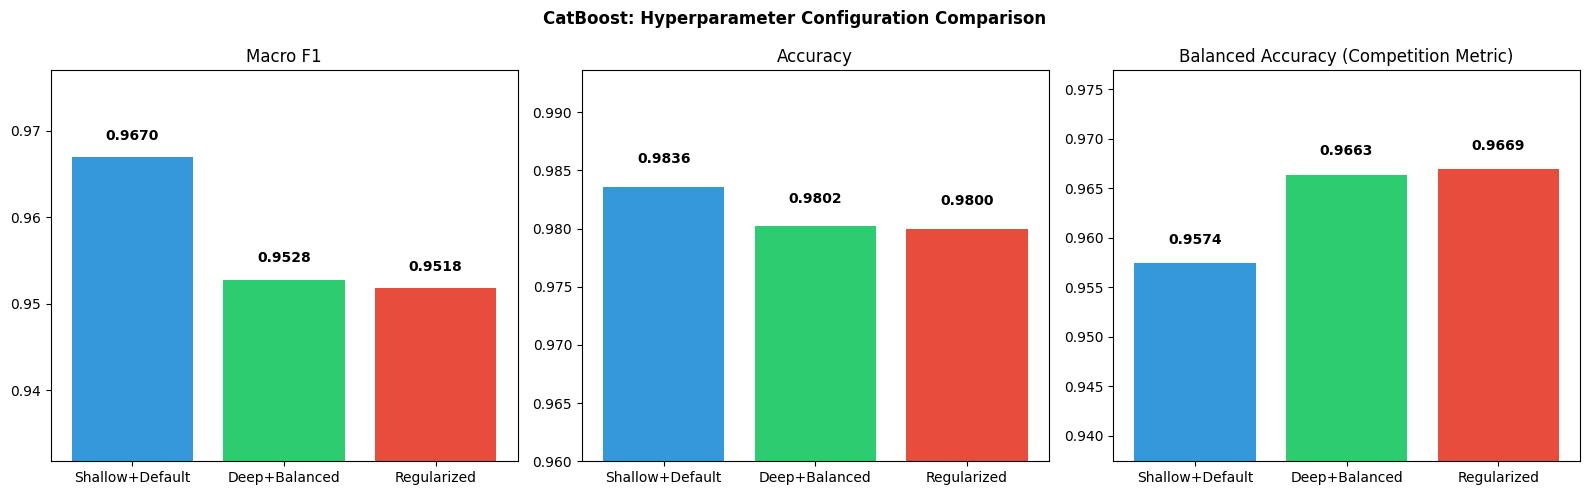

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['macro_f1', 'accuracy', 'balanced_accuracy']
titles = ['Macro F1', 'Accuracy', 'Balanced Accuracy (Competition Metric)']
labels = ['Shallow+Default', 'Deep+Balanced', 'Regularized']

for ax, metric, title in zip(axes, metrics, titles):
    vals = comparison[metric].values
    bars = ax.bar(labels, vals, color=['#3498db', '#2ecc71', '#e74c3c'])
    ax.set_title(title)
    ax.set_ylim(min(vals) - 0.02, max(vals) + 0.01)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.4f}',
                ha='center', fontweight='bold', fontsize=10)

plt.suptitle('CatBoost: Hyperparameter Configuration Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

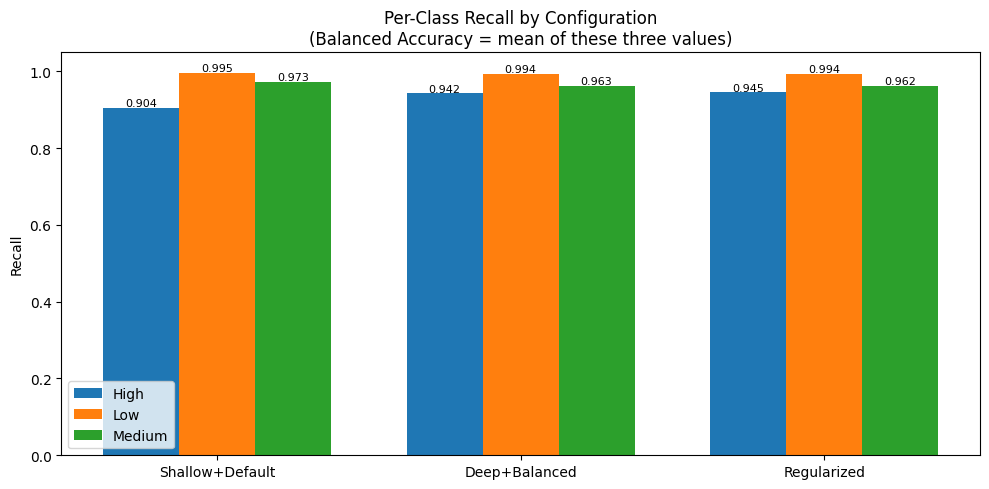

In [11]:
# per-class recall comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.25

for i, cls in enumerate(['High', 'Low', 'Medium']):
    vals = comparison[f'recall_{cls}'].values
    ax.bar(x + i*width, vals, width, label=cls)
    for j, v in enumerate(vals):
        ax.text(x[j] + i*width, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(['Shallow+Default', 'Deep+Balanced', 'Regularized'])
ax.set_ylabel('Recall')
ax.set_title('Per-Class Recall by Configuration\n(Balanced Accuracy = mean of these three values)')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Interpretation

Adding `auto_class_weights="Balanced"` (Config 1 → Config 2) improved balanced accuracy from 0.9574 to 0.9663, driven by High recall jumping from 0.9042 to 0.9424. This came at a visible cost to other metrics — macro F1 dropped from 0.9670 to 0.9528 and accuracy from 0.9836 to 0.9802. This illustrates the fundamental trade-off: class weighting sacrifices some precision on the majority classes to improve recall on the minority class. For this competition (scored on balanced accuracy), that trade-off is clearly worth it.

Config 3 (Regularized + Subsampled) provided a small further gain to 0.9669, with High recall reaching 0.9450. The L2 regularization (`l2_leaf_reg=10`) and Bernoulli subsampling (`subsample=0.7`) helped marginally, but the fold variance was comparable across configs (+/- 0.0018 to 0.0021), suggesting Config 2 was not overfitting significantly.

Optuna's best trial achieved 0.9672 balanced accuracy — only 0.0003 above Config 3. Interestingly, Optuna selected `depth=4` (the same as Config 1) with `auto_class_weights="Balanced"`, `learning_rate=0.103`, and light regularization (`l2_leaf_reg=0.25`). This suggests that for CatBoost, shallow symmetric trees with class balancing are sufficient — deeper trees add complexity without meaningful improvement. On the held-out validation set, the Optuna model achieved 0.9703 balanced accuracy with 96% High recall, 99% Low recall, and 96% Medium recall.

---
## Optuna tuning (optimizing balanced accuracy)

In [12]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 500),
        'depth': trial.suggest_int('depth', 4, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'bootstrap_type': 'Bernoulli',
        'auto_class_weights': trial.suggest_categorical(
            'auto_class_weights', [None, 'Balanced']),
    }

    baccs = []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        Xf_tr, Xf_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        yf_tr, yf_va = y_train[tr_idx], y_train[va_idx]

        m = CatBoostClassifier(**params, random_seed=42, verbose=0,
                              cat_features=cat_cols, task_type='GPU')
        m.fit(Xf_tr, yf_tr, eval_set=(Xf_va, yf_va), early_stopping_rounds=50)
        baccs.append(balanced_accuracy_score(yf_va, m.predict(Xf_va).astype(int)))
    return np.mean(baccs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f'Best Balanced Accuracy: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/15 [00:00<?, ?it/s]

Best Balanced Accuracy: 0.9672
Best params: {'iterations': 309, 'depth': 4, 'learning_rate': 0.10256387270519285, 'l2_leaf_reg': 0.2525128585174607, 'min_data_in_leaf': 9, 'subsample': 0.8063991546969127, 'auto_class_weights': 'Balanced'}


In [13]:
# evaluate best Optuna config on held-out val set
best_params = study.best_params.copy()
best_params['bootstrap_type'] = 'Bernoulli'

cat_best = CatBoostClassifier(**best_params, random_seed=42, verbose=0,
                              cat_features=cat_cols, task_type='GPU')
cat_best.fit(X_train, y_train)
y_pred = cat_best.predict(X_val).astype(int)

print(f'Validation Macro F1:          {f1_score(y_val, y_pred, average="macro"):.4f}')
print(f'Validation Accuracy:          {accuracy_score(y_val, y_pred):.4f}')
print(f'Validation Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred):.4f}')
print()
print(classification_report(y_val, y_pred, target_names=target_le.classes_))

Validation Macro F1:          0.9520
Validation Accuracy:          0.9800
Validation Balanced Accuracy: 0.9703

              precision    recall  f1-score   support

        High       0.84      0.96      0.89      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.98      0.96      0.97     47815

    accuracy                           0.98    126000
   macro avg       0.94      0.97      0.95    126000
weighted avg       0.98      0.98      0.98    126000



---
## Feature importance

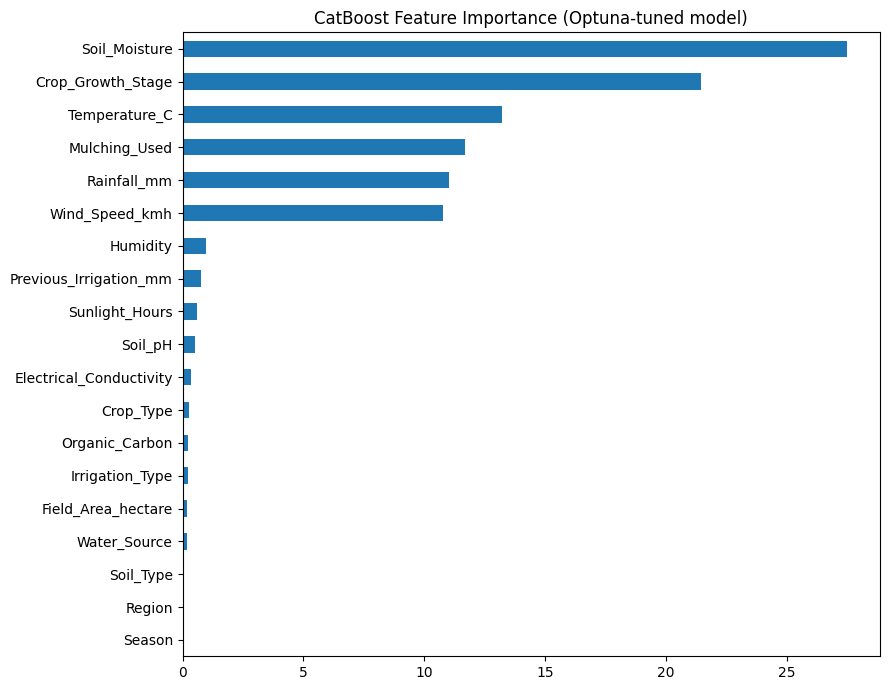


Top 5 features:
  Soil_Moisture: 27.5
  Crop_Growth_Stage: 21.5
  Temperature_C: 13.2
  Mulching_Used: 11.7
  Rainfall_mm: 11.0


In [14]:
importances = pd.Series(cat_best.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(9, 7), title='CatBoost Feature Importance (Optuna-tuned model)')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat}: {imp:.1f}')

### Feature importance discussion

CatBoost's top 5 features are Soil_Moisture (27.5), Crop_Growth_Stage (21.5), Temperature_C (13.2), Mulching_Used (11.7), and Rainfall_mm (11.0). All five are from Deotte's 6-feature formula, and Wind_Speed_kmh is likely ranked 6th.

Notably, CatBoost ranked the two categorical features — Crop_Growth_Stage and Mulching_Used — much higher than LightGBM did. In LightGBM, Crop_Growth_Stage ranked 5th (1506 splits) and Mulching_Used fell outside the top 5 entirely. CatBoost's ordered target statistics extract more signal from categorical features than LightGBM's integer-based category splits, which explains this difference. Despite the different ranking order, both models agree on *which* features matter — validating that the real signal lives in Deotte's 6 features and the remaining 13 columns are noise from synthetic data generation.

---
## Generate submission

In [15]:
best_params_final = study.best_params.copy()
best_params_final['bootstrap_type'] = 'Bernoulli'

cat_final = CatBoostClassifier(**best_params_final, random_seed=42, verbose=0,
                               cat_features=cat_cols, task_type='GPU')
cat_final.fit(X, y_enc)
preds = cat_final.predict(X_test).astype(int)
preds_labels = target_le.inverse_transform(preds)

submission = sample_sub.copy()
submission['Irrigation_Need'] = preds_labels
submission.to_csv('/kaggle/working/catboost_submission.csv', index=False)
print('Prediction distribution:')
print(submission['Irrigation_Need'].value_counts())
print()
print(submission.head())

Prediction distribution:
Irrigation_Need
Low       159634
Medium    100172
High       10194
Name: count, dtype: int64

       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
